# Lab 7 Report: 
## CIFAR-10 Classification with ResNet

In [1]:
import torch
import time
import numpy as np
import seaborn as sns

In [2]:
from IPython.display import Image # For displaying images in colab jupyter cell

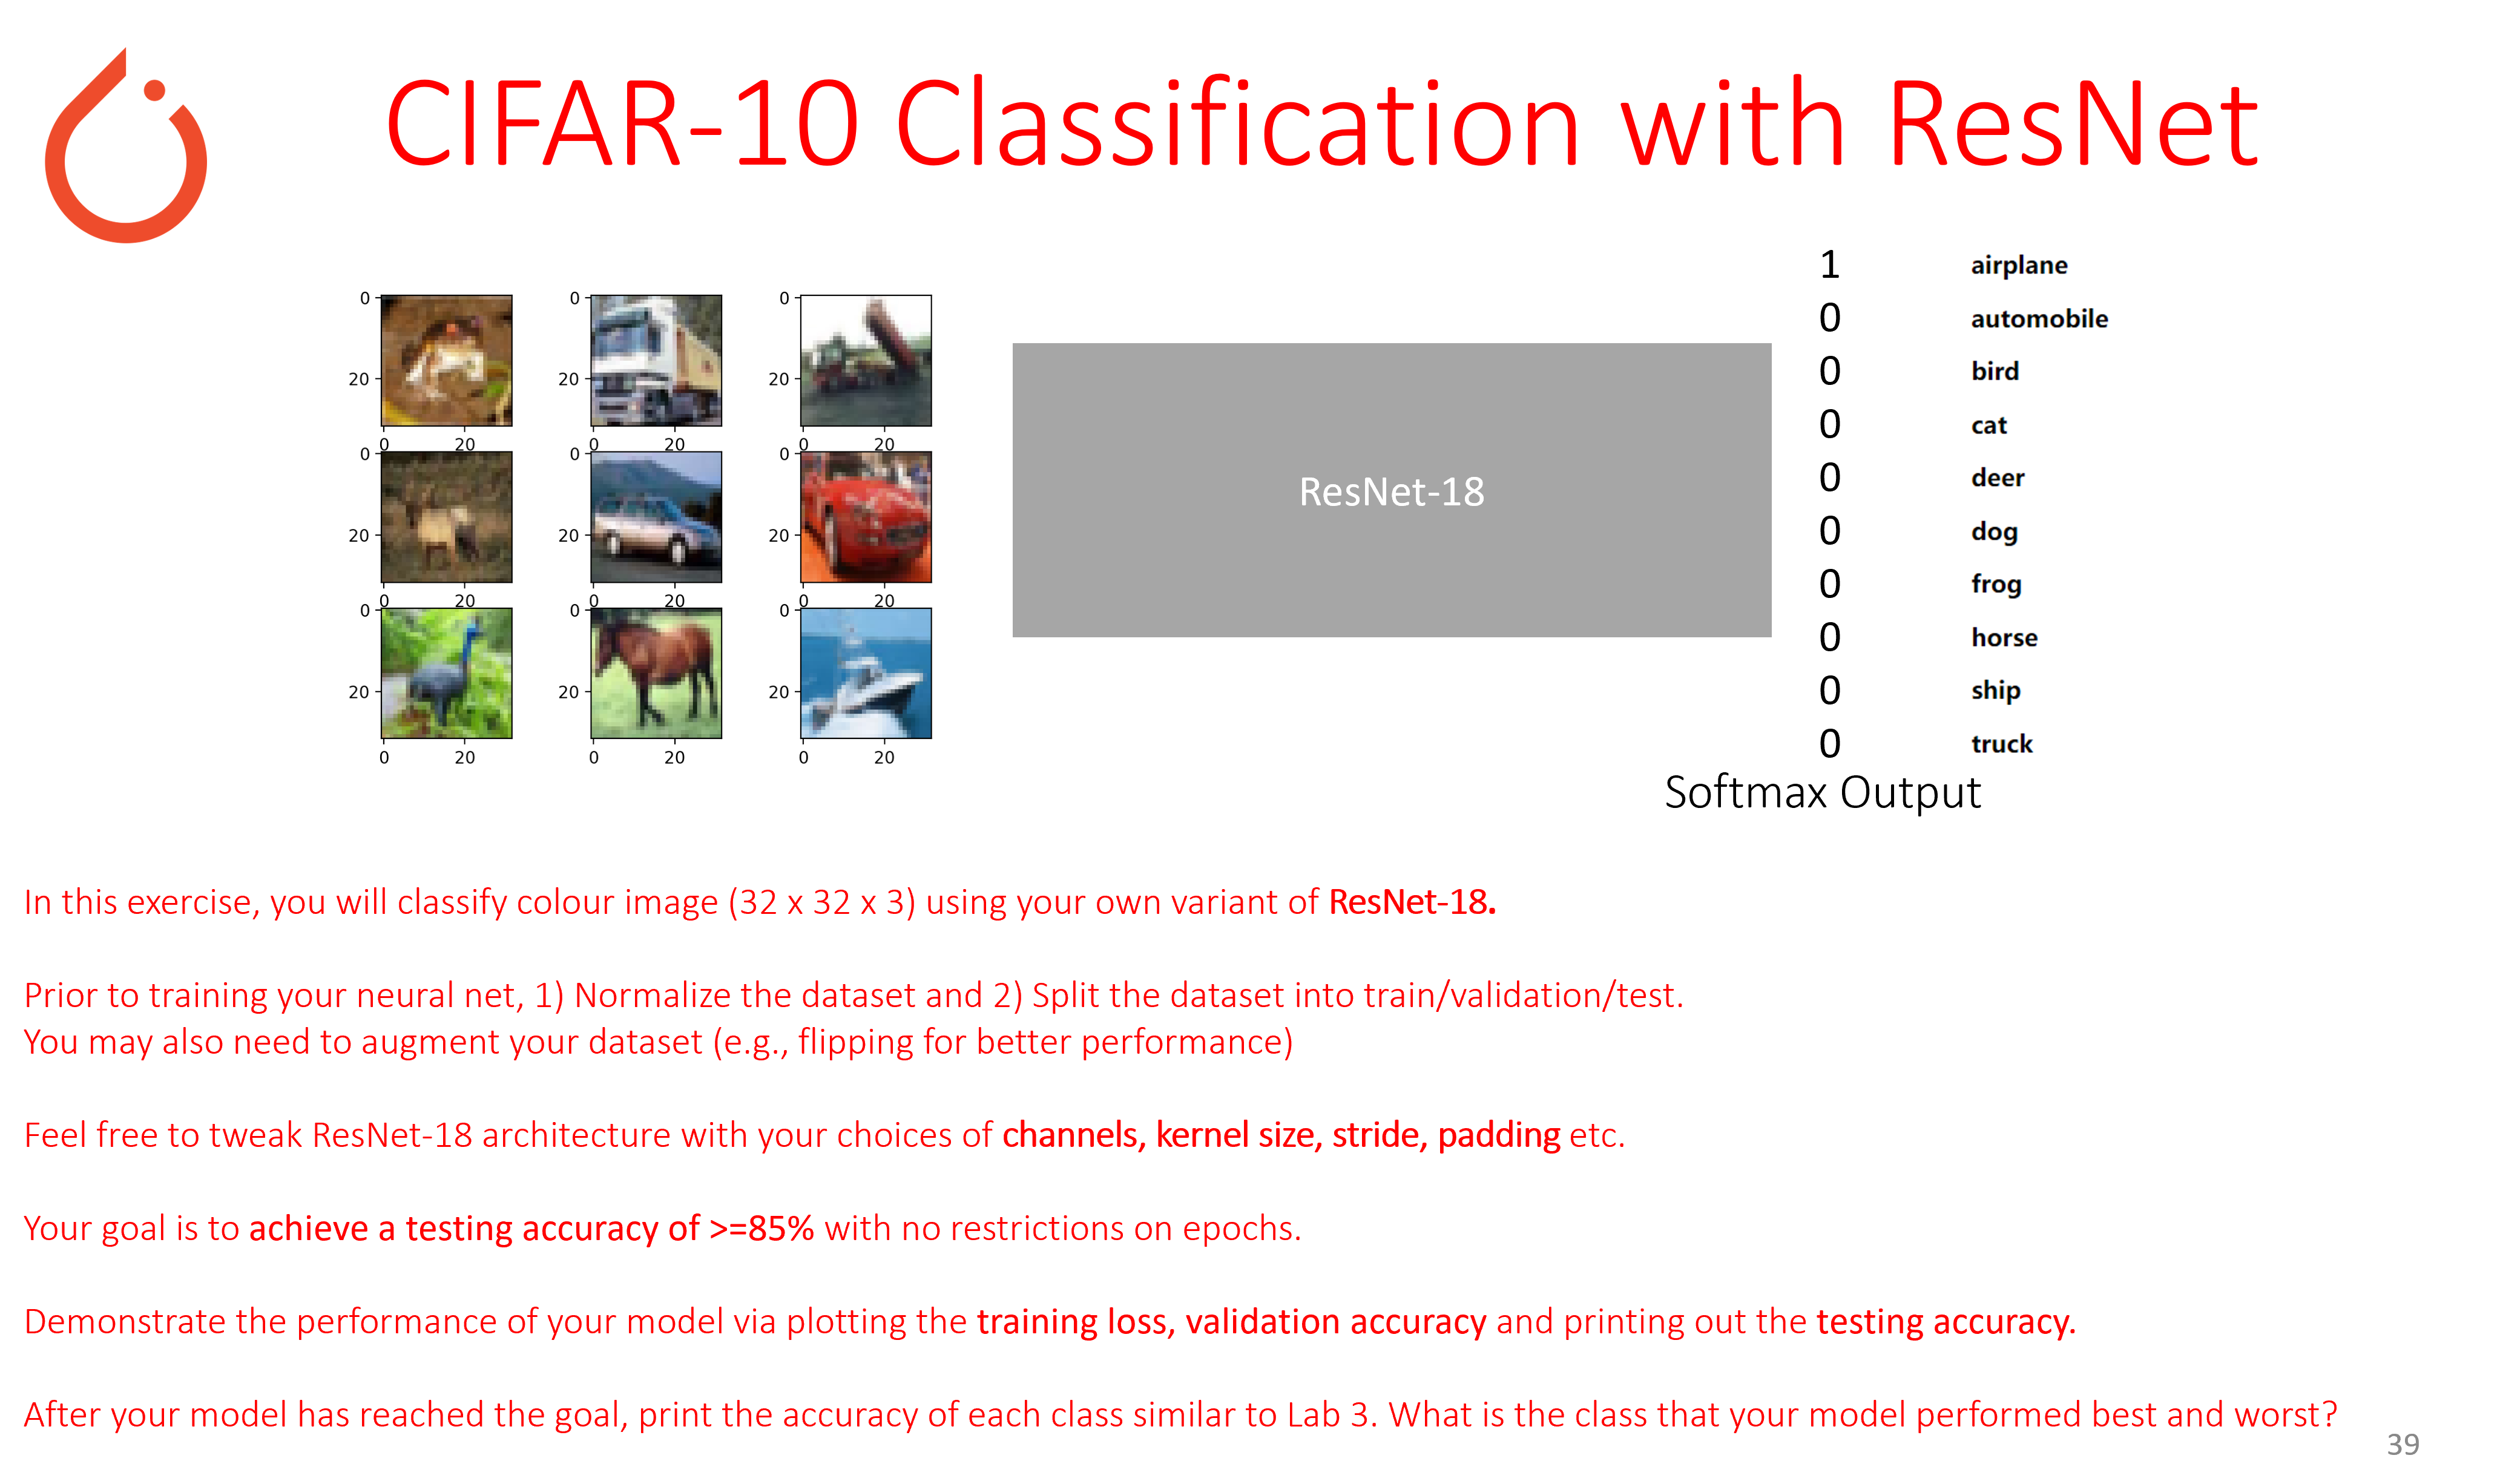

In [3]:
Image('lab7_exercise.png', width = 1000)

## Prepare Data

In [ ]:
from torchvision import datasets, transforms

# Modified for data augmentation
train_transform = transforms.Compose([
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor()
])

# No augmentation on testing set
test_transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)
test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

Files already downloaded and verified
Files already downloaded and verified


## Define Model

In [5]:
from torchvision.models import resnet18

In [6]:
class CIFAR_ResNet_Classifier(torch.nn.Module):
    
    def __init__(self, out_channels, kernel_size, stride, padding):
        
        super(CIFAR_ResNet_Classifier, self).__init__()

        self.resnet = resnet18()
        
        self.resnet.conv1 = torch.nn.Conv2d(3, out_channels, 
                                      kernel_size=(kernel_size, kernel_size), 
                                      stride=(stride, stride), 
                                      padding=(padding, padding), 
                                      bias=False)
        
        self.resnet.fc = torch.nn.Linear(self.resnet.fc.in_features, 10)

    def forward(self, x):
        
        return self.resnet(x)

## Define Hyperparameters

In [ ]:
CIFAR_ResNet_Classifier = CIFAR_ResNet_Classifier(out_channels = 64,
                                                   kernel_size = 3,
                                                   stride = 1,
                                                   padding = 3)

# Define learning rate and epochs
learning_rate = 0.01      
epochs = 80

# Batch size for mini-batch gradient
batchsize = 256

# Using Adam as optimizer
loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CIFAR_ResNet_Classifier.parameters(), lr=learning_rate)

CIFAR_ResNet_Classifier.cuda()

CIFAR_ResNet_Classifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

## Identify Tracked values

In [8]:
train_loss_list = []

## Train Model

In [9]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batchsize, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False
)

In [ ]:
# Start timing
training_start_time = time.time()

for epoch in range(epochs):
    
    for batch_idx, (train_input, train_target) in enumerate(train_loader):
        
        optimizer.zero_grad()
        
        pred = CIFAR_ResNet_Classifier(train_input.cuda())
        
        loss = loss_func(pred, train_target.cuda())
        
        loss.backward()
        
        optimizer.step()
            
    print("Train Epoch: {} \tLoss: {:.6f}".format(epoch, loss.item()))

# End timing
training_end_time = time.time()
training_time = training_end_time - training_start_time
print(f"\nTotal training time: {training_time:.2f} seconds")

## Visualize and Evaluate Model
### Logging accuracy and run parameters

In [ ]:
import os
from datetime import datetime


def log_test_accuracy(accuracy_percent, training_time_seconds=None, log_file="log.md"):

    log_path = log_file
    
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    log_entry = f"## {timestamp}\nTest Accuracy: {accuracy_percent:.2f}%\n"
    
    if training_time_seconds is not None:
        # Format time as hours:minutes:seconds
        hours = int(training_time_seconds // 3600)
        minutes = int((training_time_seconds % 3600) // 60)
        seconds = int(training_time_seconds % 60)
        
        if hours > 0:
            time_str = f"{hours}h {minutes}m {seconds}s"
        elif minutes > 0:
            time_str = f"{minutes}m {seconds}s"
        else:
            time_str = f"{seconds}s"
        
        log_entry += f"Training Time: {time_str}\n"
    
    log_entry += "\n"
    
    with open(log_path, "a") as f:
        f.write(log_entry)
    
    print(f"Test accuracy logged to {log_path}")



In [ ]:
CIFAR_ResNet_Classifier.eval()
test_loss = 0
correct = 0

with torch.no_grad():
    
    for test_input, test_target in test_loader:
        
        output = CIFAR_ResNet_Classifier(test_input.cuda())
        
        test_loss += loss_func(output, test_target.cuda()).item()
        
        pred = output.argmax(dim=1, keepdim=True)
        
        correct += pred.eq(test_target.view_as(pred).cuda()).sum().item()

In [ ]:
test_loss /= len(test_loader.dataset)

test_accuracy_percent = 100.0 * correct / len(test_loader.dataset)
print("Test Accuracy: {}/{} ({:.0f}%)\n".format(correct, len(test_loader.dataset), test_accuracy_percent))

# Log the test accuracy with training time
log_test_accuracy(test_accuracy_percent, training_time)

Test Accuracy: 8653/10000 (87%)

Test accuracy logged to log.md


# Notes

- Most changes had minor impact
- Dramtically increasing epochs 10 -> 60 had a huge impact
    - Might not have been possible without GPU
- Internet suggest 80 or even 100+ epochs

## Logistic notes
- Wanted to ouptut of jupyter python cell to append to md block
- Instead loged to external log.md and pasted below
- Tagging each run with change implemented
    - Had to save and close the log after each run to avoid overwriting

## Internet suggestions
- Unfamiliar modifications were suggested but not implemented
    - AMP: Automatic Mixed precision
        - Uses 16 bit instead of 32 bit for much fater training
        - Reduces memory uses to allow for larger batch sizes
    - Cosine Learning Rate Schedule
        - LR starts high then decreases following a cosine curve
    - Label smoothing
        - Turns one-hot labels to fractional values to smooth them out
    - Mixup/CutMix
        - Combines two images and their labels linearly
        - CutMix: Cuts a patch from one image and pastes it into another mixing labels porportiaonally
        - encourage strong regularization.
        - Good for small datasets
    - EMA: Exponential Moving Average of Weights
        - Smoothed version of model weights during training
        - Reduces noise for SGD update
        - Often gives better validation accuracy than the raw model 

# Log
## 2025-11-11 19:17:12
Test Accuracy: 72.15%
Training Time: 1m 38s
- [x] Vanilla, straight copy from example notebook
## 2025-11-11 19:21:08
Test Accuracy: 73.42%
Training Time: 1m 6s
- [x] Batch size 64 -> 128
## 2025-11-11 19:23:10
Test Accuracy: 56.78%
Training Time: 1m 5s
- [ ] Learning rate: 0.001 -> 0.0001
## 2025-11-11 19:27:39
Test Accuracy: 71.63%
Training Time: 1m 6s
- [ ] Kernel size: 7 -> 10
## 2025-11-11 19:44:08
Test Accuracy: 74.13%
Training Time: 1m 9s
- [x] Kernel size 7 -> 3
## 2025-11-11 19:47:02
Test Accuracy: 79.69%
Training Time: 1m 45s
-[x] Stride: 2 -> 1
## 2025-11-11 19:49:34
Test Accuracy: 78.95%
Training Time: 1m 17s
- [ ] Padding 3 -> 1
## 2025-11-11 19:57:50
Test Accuracy: 80.32%
Training Time: 2m 52s
- [ ] Data Augmentation
## 2025-11-11 21:09:58
Test Accuracy: 86.53%
Training Time: 1h 11m 8s
- [x] Epochs: 10 -> 60
